# Task 1: GPT-based Triage Acuity Prediction

This notebook evaluates GPT as a large language model classifier for Task 1 triage acuity prediction.

Unlike the traditional machine learning notebook, this experiment does not train a model. Instead, each patient record is converted into a prompt containing early triage information, including chief complaint, vital signs, gender, and arrival transport. GPT is then asked to predict the acuity level from 1 to 4.

The GPT results will be evaluated using accuracy, macro F1-score, weighted F1-score, confusion matrix, under-triage, and over-triage. The results will then be compared with the tuned XGBoost model from the machine learning experiment.

## Step 1: Import required libraries

This step imports the libraries needed for data loading, sampling, prompt generation, and evaluation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

## Step 2: Load the Task 1 dataset

This step loads the original Task 1 dataset with chief complaint, vital signs, gender, arrival transport, and acuity labels.

Unlike the machine learning notebook, this GPT experiment keeps the patient information in a readable text format because GPT needs natural language input rather than one-hot encoded features.

In [2]:
DATA_PATH = "task1_acuity_with_vitals.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully.
Dataset shape: (106284, 17)


C:\Users\Allen\AppData\Local\Temp\ipykernel_2796\710537240.py:3: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(DATA_PATH)


,subject_id,hadm_id,stay_id,gender,arrival_transport,chiefcomplaint,chief_complaint,chief_text,temperature,heartrate,resprate,o2sat,sbp,dbp,pain,acuity,raw_row_length
0,16070390,20482734,NaN,F,AMBULANCE,s/p Fall,"trauma, hypoxia","s/p fall [SEP] trauma, hypoxia",98.5,83.0,18.0,98.0,163.0,45.0,3.0,2,949
1,19249493,27215580,NaN,F,WALK IN,Abd pain,"abdominal pain radiating to back, nausea, vomi...",abd pain [SEP] abdominal pain radiating to bac...,98.8,112.0,20.0,99.0,120.0,74.0,8.0,3,949
2,17649604,26921204,38186397.0,F,AMBULANCE,"NSTEMI, Transfer","cool skin, nausea, malaise","nstemi, transfer [SEP] cool skin, nausea, malaise",98.7,90.0,16.0,98.0,116.0,58.0,0.0,2,947
3,17392822,28381240,NaN,M,WALK IN,"Dyspnea, Chest pain","dyspnea on exertion, pleuritic chest pain, pro...","dyspnea, chest pain [SEP] dyspnea on exertion,...",98.8,95.0,20.0,100.0,119.0,64.0,7.0,2,948
4,16237818,29461643,NaN,F,WALK IN,BRBPR,"loose, bloody stools","brbpr [SEP] loose, bloody stools",97.7,79.0,20.0,97.0,140.0,76.0,0.0,2,947


## Step 3: Prepare the LLM-ready dataset

This step prepares the dataset for the GPT-based acuity prediction experiment.

The filtering strategy follows the previous-group-style machine learning experiment as closely as possible. Records with missing vital signs are removed, obvious vital sign outliers are excluded, and acuity level 5 is removed so that the final task uses acuity levels 1 to 4.

However, unlike the machine learning experiment, this notebook keeps the patient information in a readable format. This allows each patient record to be converted into a prompt for GPT.

In [3]:
# Create a copy for the GPT experiment
df_llm = df.copy()

# Store record counts for reporting
record_log = []

def log_records(stage_name, data):
    record_log.append({
        "Stage": stage_name,
        "Records": len(data)
    })

log_records("Original dataset", df_llm)


# -------------------------------
# 1. Clean chief complaint text
# -------------------------------

df_llm["chiefcomplaint_clean"] = (
    df_llm["chiefcomplaint"]
    .fillna("")
    .astype(str)
    .str.lower()
    .str.strip()
)

# Standardise comma spacing
df_llm["chiefcomplaint_clean"] = (
    df_llm["chiefcomplaint_clean"]
    .str.replace(r"\s*,\s*", ", ", regex=True)
)

# Remove empty or redacted chief complaints
df_llm = df_llm[df_llm["chiefcomplaint_clean"] != ""]
df_llm = df_llm[~df_llm["chiefcomplaint_clean"].str.contains("___", na=False)]

log_records("After removing empty or redacted chief complaints", df_llm)


# -------------------------------
# 2. Convert acuity and vital signs to numeric values
# -------------------------------

numeric_features = [
    "temperature", "heartrate", "resprate", "o2sat", "sbp", "dbp", "pain"
]

df_llm["acuity"] = pd.to_numeric(df_llm["acuity"], errors="coerce")

for col in numeric_features:
    df_llm[col] = pd.to_numeric(df_llm[col], errors="coerce")


# -------------------------------
# 3. Remove records with missing acuity or vital signs
# -------------------------------

df_llm = df_llm.dropna(subset=["acuity"] + numeric_features)

df_llm["acuity"] = df_llm["acuity"].astype(int)

log_records("After removing records with missing acuity or vital signs", df_llm)


# -------------------------------
# 4. Remove obvious vital sign outliers
# -------------------------------

df_llm = df_llm[~((df_llm["temperature"] < 40) | (df_llm["temperature"] > 120))]
df_llm = df_llm[~((df_llm["heartrate"] < 10) | (df_llm["heartrate"] > 250))]
df_llm = df_llm[~((df_llm["resprate"] < 5) | (df_llm["resprate"] > 100))]
df_llm = df_llm[~((df_llm["o2sat"] < 30) | (df_llm["o2sat"] > 100))]
df_llm = df_llm[~((df_llm["sbp"] < 20) | (df_llm["sbp"] > 300))]
df_llm = df_llm[~(df_llm["dbp"] > 200)]
df_llm = df_llm[~(df_llm["pain"] > 10)]

log_records("After removing obvious vital sign outliers", df_llm)


# -------------------------------
# 5. Exclude acuity level 5
# -------------------------------

df_llm = df_llm[df_llm["acuity"].between(1, 4)]

log_records("After excluding acuity level 5", df_llm)


# -------------------------------
# 6. Keep only records with frequent chief complaint categories
# -------------------------------

complaint_dummies = df_llm["chiefcomplaint_clean"].str.get_dummies(sep=", ")
complaint_dummies = complaint_dummies.add_prefix("cc_")

# Merge common abbreviations into standard complaint columns
def merge_complaint_abbreviation(source_col, target_col):
    if source_col in complaint_dummies.columns:
        if target_col not in complaint_dummies.columns:
            complaint_dummies[target_col] = 0

        complaint_dummies[target_col] = (
            complaint_dummies[target_col] + complaint_dummies[source_col]
        )

        complaint_dummies.drop(columns=[source_col], inplace=True)


merge_complaint_abbreviation("cc_cp", "cc_chest pain")
merge_complaint_abbreviation("cc_abd pain", "cc_abdominal pain")
merge_complaint_abbreviation("cc_abdo pain", "cc_abdominal pain")

# Keep only frequent complaints, matching the ML experiment
complaint_threshold = 100
complaint_counts = complaint_dummies.sum()

complaint_dummies = complaint_dummies.loc[
    :,
    complaint_counts[complaint_counts >= complaint_threshold].index
]

# Remove records without any retained complaint feature
complaint_row_sum = complaint_dummies.sum(axis=1)

df_llm = df_llm.loc[complaint_row_sum > 0].copy()

log_records("After retaining frequent chief complaint records", df_llm)


# -------------------------------
# 7. Keep only useful readable columns for GPT
# -------------------------------

llm_columns = [
    "gender",
    "arrival_transport",
    "chiefcomplaint_clean",
    "temperature",
    "heartrate",
    "resprate",
    "o2sat",
    "sbp",
    "dbp",
    "pain",
    "acuity"
]

df_llm = df_llm[llm_columns].reset_index(drop=True)

print("Final LLM-ready dataset shape:", df_llm.shape)

print("\nFinal acuity distribution:")
display(df_llm["acuity"].value_counts().sort_index().to_frame("Count"))

print("\nRecord count after each processing stage:")
display(pd.DataFrame(record_log))

df_llm.head()

Final LLM-ready dataset shape: (78252, 11)

Final acuity distribution:


,Count
acuity,
1,4520
2,40851
3,32680
4,201



Record count after each processing stage:


,Stage,Records
0,Original dataset,106284
1,After removing empty or redacted chief complaints,106127
2,After removing records with missing acuity or ...,96490
3,After removing obvious vital sign outliers,92707
4,After excluding acuity level 5,92700
5,After retaining frequent chief complaint records,78252


,gender,arrival_transport,chiefcomplaint_clean,temperature,heartrate,resprate,o2sat,sbp,dbp,pain,acuity
0,F,AMBULANCE,s/p fall,98.5,83.0,18.0,98.0,163.0,45.0,3.0,2
1,F,WALK IN,abd pain,98.8,112.0,20.0,99.0,120.0,74.0,8.0,3
2,F,AMBULANCE,"nstemi, transfer",98.7,90.0,16.0,98.0,116.0,58.0,0.0,2
3,M,WALK IN,"dyspnea, chest pain",98.8,95.0,20.0,100.0,119.0,64.0,7.0,2
4,F,WALK IN,brbpr,97.7,79.0,20.0,97.0,140.0,76.0,0.0,2


## Step 4: Create the same style of train-test split

This step creates an 80/20 stratified train-test split.

The GPT experiment will use samples from the test set only. This avoids testing GPT on records that would belong to the training side of the machine learning experiment.

In [4]:
# Define target
y = df_llm["acuity"]

# Create stratified train-test split
train_index, test_index = train_test_split(
    df_llm.index,
    test_size=0.2,
    stratify=y,
    random_state=42
)

df_llm_train = df_llm.loc[train_index].reset_index(drop=True)
df_llm_test = df_llm.loc[test_index].reset_index(drop=True)

print("LLM training-side records:", len(df_llm_train))
print("LLM test-side records:", len(df_llm_test))

print("\nTest set acuity distribution:")
display(df_llm_test["acuity"].value_counts().sort_index().to_frame("Test Count"))

LLM training-side records: 62601
LLM test-side records: 15651

Test set acuity distribution:


,Test Count
acuity,
1,904
2,8171
3,6536
4,40


## Step 5: Create a balanced sample for GPT evaluation

Running GPT on the full test set would be expensive and time-consuming. Therefore, this step creates a smaller balanced sample from the test set.

The same balanced sample can also be used by Gemini and the local Ollama model, making the LLM comparison fair.

In [5]:
# Number of records to sample from each acuity class
SAMPLE_PER_CLASS = 100

gpt_sample = (
    df_llm_test
    .groupby("acuity", group_keys=False)
    .apply(lambda x: x.sample(n=min(SAMPLE_PER_CLASS, len(x)), random_state=42))
    .reset_index(drop=True)
)

print("GPT sample shape:", gpt_sample.shape)

print("\nGPT sample acuity distribution:")
display(gpt_sample["acuity"].value_counts().sort_index().to_frame("Sample Count"))

gpt_sample.head()

GPT sample shape: (340, 11)

GPT sample acuity distribution:


C:\Users\Allen\AppData\Local\Temp\ipykernel_2796\1524717879.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_llm_test


,Sample Count
acuity,
1,100
2,100
3,100
4,40


,gender,arrival_transport,chiefcomplaint_clean,temperature,heartrate,resprate,o2sat,sbp,dbp,pain,acuity
0,F,WALK IN,"si, sa",98.2,81.0,16.0,100.0,128.0,83.0,0.0,1
1,M,WALK IN,hypoxia,97.3,57.0,18.0,89.0,133.0,62.0,7.0,1
2,F,AMBULANCE,"n/v/d, hypotension",99.5,114.0,18.0,98.0,83.0,48.0,0.0,1
3,M,WALK IN,"dyspnea, weakness",97.5,131.0,18.0,96.0,112.0,86.0,0.0,1
4,M,WALK IN,n/v,96.2,116.0,18.0,100.0,82.0,64.0,0.0,1


## Step 6: Generate GPT prompts

This step converts each patient record in the balanced test sample into a GPT prompt.

Each prompt contains only early triage information, including chief complaint, vital signs, gender, and arrival transport. The true acuity label is not included in the prompt because it is used only for evaluation.

GPT is asked to return only one acuity level from 1 to 4.

In [6]:
def create_gpt_prompt(row):
    """
    Create one GPT prompt from a patient record.

    The prompt only includes early triage information.
    The true acuity label is not included.
    """
    
    gender = row.get("gender", "Unknown")
    arrival_transport = row.get("arrival_transport", "Unknown")
    chief_complaint = row.get("chiefcomplaint_clean", "Unknown")
    
    temperature = row.get("temperature", "Unknown")
    heartrate = row.get("heartrate", "Unknown")
    resprate = row.get("resprate", "Unknown")
    o2sat = row.get("o2sat", "Unknown")
    sbp = row.get("sbp", "Unknown")
    dbp = row.get("dbp", "Unknown")
    pain = row.get("pain", "Unknown")

    prompt = f"""
You are an emergency triage assistant.

Based only on the early triage information below, predict the patient's triage acuity level.

Acuity scale:
1 = most urgent
2 = urgent
3 = less urgent
4 = least urgent

Patient information:
Chief complaint: {chief_complaint}
Gender: {gender}
Arrival transport: {arrival_transport}
Temperature: {temperature}
Heart rate: {heartrate}
Respiratory rate: {resprate}
Oxygen saturation: {o2sat}
Systolic blood pressure: {sbp}
Diastolic blood pressure: {dbp}
Pain score: {pain}

Return only one number: 1, 2, 3, or 4.
"""
    return prompt.strip()


# Create prompts for all records in the GPT sample
gpt_sample["prompt"] = gpt_sample.apply(create_gpt_prompt, axis=1)

print("Prompts generated successfully.")
print("Number of prompts:", len(gpt_sample))

gpt_sample[["acuity", "prompt"]].head()

Prompts generated successfully.
Number of prompts: 340


,acuity,prompt
0,1,You are an emergency triage assistant.\n\nBase...
1,1,You are an emergency triage assistant.\n\nBase...
2,1,You are an emergency triage assistant.\n\nBase...
3,1,You are an emergency triage assistant.\n\nBase...
4,1,You are an emergency triage assistant.\n\nBase...


## Step 7: Inspect example prompts

This step checks a few generated prompts to make sure the patient information is correctly formatted and the true acuity label is not included in the prompt.

The true acuity label is kept separately for evaluation only.

In [7]:
# Display one example prompt

example_index = 0

print("True acuity label for evaluation:", gpt_sample.loc[example_index, "acuity"])
print("\nGenerated GPT prompt:")
print("-" * 80)
print(gpt_sample.loc[example_index, "prompt"])

True acuity label for evaluation: 1

Generated GPT prompt:
--------------------------------------------------------------------------------
You are an emergency triage assistant.

Based only on the early triage information below, predict the patient's triage acuity level.

Acuity scale:
1 = most urgent
2 = urgent
3 = less urgent
4 = least urgent

Patient information:
Chief complaint: si, sa
Gender: F
Arrival transport: WALK IN
Temperature: 98.2
Heart rate: 81.0
Respiratory rate: 16.0
Oxygen saturation: 100.0
Systolic blood pressure: 128.0
Diastolic blood pressure: 83.0
Pain score: 0.0

Return only one number: 1, 2, 3, or 4.


## Step 8: Save the LLM evaluation sample

This step saves the balanced evaluation sample and generated prompts to a CSV file.

The same CSV file can be shared with teammates who are testing Gemini and local Ollama. Using the same evaluation sample makes the comparison between GPT, Gemini, Ollama, and the machine learning models fairer.

In [8]:
# Add a sample ID for tracking predictions later
gpt_sample = gpt_sample.reset_index(drop=True)
gpt_sample["sample_id"] = range(1, len(gpt_sample) + 1)

# Reorder columns for easier review
export_columns = [
    "sample_id",
    "acuity",
    "chiefcomplaint_clean",
    "gender",
    "arrival_transport",
    "temperature",
    "heartrate",
    "resprate",
    "o2sat",
    "sbp",
    "dbp",
    "pain",
    "prompt"
]

gpt_sample_export = gpt_sample[export_columns]

# Save sample and prompts
gpt_sample_export.to_csv("task1_llm_evaluation_sample.csv", index=False)

print("LLM evaluation sample saved as task1_llm_evaluation_sample.csv")
print("Saved rows:", len(gpt_sample_export))

gpt_sample_export.head()

LLM evaluation sample saved as task1_llm_evaluation_sample.csv
Saved rows: 340


,sample_id,acuity,chiefcomplaint_clean,gender,arrival_transport,temperature,heartrate,resprate,o2sat,sbp,dbp,pain,prompt
0,1,1,"si, sa",F,WALK IN,98.2,81.0,16.0,100.0,128.0,83.0,0.0,You are an emergency triage assistant.\n\nBase...
1,2,1,hypoxia,M,WALK IN,97.3,57.0,18.0,89.0,133.0,62.0,7.0,You are an emergency triage assistant.\n\nBase...
2,3,1,"n/v/d, hypotension",F,AMBULANCE,99.5,114.0,18.0,98.0,83.0,48.0,0.0,You are an emergency triage assistant.\n\nBase...
3,4,1,"dyspnea, weakness",M,WALK IN,97.5,131.0,18.0,96.0,112.0,86.0,0.0,You are an emergency triage assistant.\n\nBase...
4,5,1,n/v,M,WALK IN,96.2,116.0,18.0,100.0,82.0,64.0,0.0,You are an emergency triage assistant.\n\nBase...


## Step 9: Run GPT prediction on a small test batch

This step sends a small number of prompts to GPT and collects the predicted acuity labels.

Only a small test batch is used first to confirm that the API call works correctly and that GPT returns one number from 1 to 4.

In [9]:
!pip install openai


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
import os
import time
from openai import OpenAI

client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

MODEL_NAME = "gpt-5.2"


def call_gpt_for_acuity(prompt):
    """
    Send one prompt to GPT and return the raw model output.
    """
    response = client.responses.create(
        model=MODEL_NAME,
        input=prompt,
        temperature=0
    )
    
    return response.output_text.strip()


# Test on the first 5 prompts only
test_batch = gpt_sample.head(5).copy()

gpt_outputs = []

for i, row in test_batch.iterrows():
    output = call_gpt_for_acuity(row["prompt"])
    gpt_outputs.append(output)
    print(f"Sample {i}: true acuity = {row['acuity']}, GPT output = {output}")
    time.sleep(0.5)

test_batch["gpt_raw_output"] = gpt_outputs

test_batch[["sample_id", "acuity", "gpt_raw_output"]]

Sample 0: true acuity = 1, GPT output = 2
Sample 1: true acuity = 1, GPT output = 2
Sample 2: true acuity = 1, GPT output = 1
Sample 3: true acuity = 1, GPT output = 2
Sample 4: true acuity = 1, GPT output = 1


,sample_id,acuity,gpt_raw_output
0,1,1,2
1,2,1,2
2,3,1,1
3,4,1,2
4,5,1,1


## Step 10: Clean GPT outputs

This step converts GPT's raw output into a numerical acuity prediction.

Although the prompt asks GPT to return only one number, the raw output is still cleaned using a regular expression. This makes the evaluation more reliable if GPT returns extra text such as "Acuity level: 2".

In [12]:
def extract_acuity_prediction(output):
    """
    Extract the first valid acuity label from GPT output.
    Valid labels are 1, 2, 3, and 4.
    """
    if pd.isna(output):
        return np.nan
    
    output = str(output).strip()
    
    match = re.search(r"\b[1-4]\b", output)
    
    if match:
        return int(match.group())
    else:
        return np.nan


test_batch["gpt_prediction"] = test_batch["gpt_raw_output"].apply(extract_acuity_prediction)

test_batch[["sample_id", "acuity", "gpt_raw_output", "gpt_prediction"]]

,sample_id,acuity,gpt_raw_output,gpt_prediction
0,1,1,2,2
1,2,1,2,2
2,3,1,1,1
3,4,1,2,2
4,5,1,1,1


## Step 11: Run GPT prediction on the full balanced sample

This step runs GPT prediction on the full balanced evaluation sample.

The prediction results are saved progressively to a CSV file. This prevents progress from being lost if the process is interrupted.

In [13]:
# Run GPT prediction on the full balanced sample with resume support

OUTPUT_PATH = "task1_gpt_predictions.csv"

# If previous prediction file exists, load it and continue from unfinished rows
try:
    existing_predictions = pd.read_csv(OUTPUT_PATH)
    completed_ids = set(existing_predictions["sample_id"].tolist())
    gpt_predictions = existing_predictions.to_dict("records")
    print("Loaded existing predictions:", len(completed_ids))
except FileNotFoundError:
    completed_ids = set()
    gpt_predictions = []
    print("No existing prediction file found. Starting from the beginning.")

for i, row in gpt_sample.iterrows():
    sample_id = row["sample_id"]
    
    # Skip already completed samples
    if sample_id in completed_ids:
        continue
    
    try:
        raw_output = call_gpt_for_acuity(row["prompt"])
        prediction = extract_acuity_prediction(raw_output)
    except Exception as e:
        raw_output = f"ERROR: {e}"
        prediction = np.nan
    
    gpt_predictions.append({
        "sample_id": sample_id,
        "true_acuity": row["acuity"],
        "gpt_raw_output": raw_output,
        "gpt_prediction": prediction,
        "chiefcomplaint_clean": row["chiefcomplaint_clean"],
        "gender": row["gender"],
        "arrival_transport": row["arrival_transport"],
        "temperature": row["temperature"],
        "heartrate": row["heartrate"],
        "resprate": row["resprate"],
        "o2sat": row["o2sat"],
        "sbp": row["sbp"],
        "dbp": row["dbp"],
        "pain": row["pain"]
    })
    
    # Save progress after each prediction
    pd.DataFrame(gpt_predictions).to_csv(OUTPUT_PATH, index=False)
    
    print(f"Completed sample_id {sample_id} | True: {row['acuity']} | GPT: {prediction}")
    
    time.sleep(0.5)

gpt_predictions_df = pd.DataFrame(gpt_predictions)

print("GPT prediction completed.")
print("Total predictions:", len(gpt_predictions_df))

display(gpt_predictions_df.head())

No existing prediction file found. Starting from the beginning.
Completed sample_id 1 | True: 1 | GPT: 2
Completed sample_id 2 | True: 1 | GPT: 2
Completed sample_id 3 | True: 1 | GPT: 1
Completed sample_id 4 | True: 1 | GPT: 2
Completed sample_id 5 | True: 1 | GPT: 1
Completed sample_id 6 | True: 1 | GPT: 2
Completed sample_id 7 | True: 1 | GPT: 2
Completed sample_id 8 | True: 1 | GPT: 2
Completed sample_id 9 | True: 1 | GPT: 1
Completed sample_id 10 | True: 1 | GPT: 1
Completed sample_id 11 | True: 1 | GPT: 2
Completed sample_id 12 | True: 1 | GPT: 2
Completed sample_id 13 | True: 1 | GPT: 1
Completed sample_id 14 | True: 1 | GPT: 2
Completed sample_id 15 | True: 1 | GPT: 2
Completed sample_id 16 | True: 1 | GPT: 2
Completed sample_id 17 | True: 1 | GPT: 2
Completed sample_id 18 | True: 1 | GPT: 3
Completed sample_id 19 | True: 1 | GPT: 2
Completed sample_id 20 | True: 1 | GPT: 2
Completed sample_id 21 | True: 1 | GPT: 2
Completed sample_id 22 | True: 1 | GPT: 2
Completed sample_id 2

,sample_id,true_acuity,gpt_raw_output,gpt_prediction,chiefcomplaint_clean,gender,arrival_transport,temperature,heartrate,resprate,o2sat,sbp,dbp,pain
0,1,1,2,2.0,"si, sa",F,WALK IN,98.2,81.0,16.0,100.0,128.0,83.0,0.0
1,2,1,2,2.0,hypoxia,M,WALK IN,97.3,57.0,18.0,89.0,133.0,62.0,7.0
2,3,1,1,1.0,"n/v/d, hypotension",F,AMBULANCE,99.5,114.0,18.0,98.0,83.0,48.0,0.0
3,4,1,2,2.0,"dyspnea, weakness",M,WALK IN,97.5,131.0,18.0,96.0,112.0,86.0,0.0
4,5,1,1,1.0,n/v,M,WALK IN,96.2,116.0,18.0,100.0,82.0,64.0,0.0


## Step 12: Check GPT prediction validity

This step checks whether GPT returned valid acuity labels for all sampled records.

Only valid predictions from 1 to 4 are used for final evaluation.

In [14]:
# Load GPT predictions if needed
gpt_predictions_df = pd.read_csv("task1_gpt_predictions.csv")

print("Total GPT predictions:", len(gpt_predictions_df))

# Check raw GPT outputs
display(gpt_predictions_df["gpt_raw_output"].value_counts(dropna=False).sort_index())

# Convert predictions to numeric
gpt_predictions_df["gpt_prediction"] = pd.to_numeric(
    gpt_predictions_df["gpt_prediction"],
    errors="coerce"
)

# Check invalid predictions
invalid_count = gpt_predictions_df["gpt_prediction"].isna().sum()

print("Invalid or missing predictions:", invalid_count)

# Keep valid predictions only
gpt_eval_df = gpt_predictions_df.dropna(subset=["gpt_prediction"]).copy()

gpt_eval_df["true_acuity"] = gpt_eval_df["true_acuity"].astype(int)
gpt_eval_df["gpt_prediction"] = gpt_eval_df["gpt_prediction"].astype(int)

# Keep only predictions from 1 to 4
gpt_eval_df = gpt_eval_df[gpt_eval_df["gpt_prediction"].between(1, 4)]

print("Valid predictions for evaluation:", len(gpt_eval_df))

display(gpt_eval_df.head())

Total GPT predictions: 340


gpt_raw_output
1                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       42
2                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      211
3                                  

Invalid or missing predictions: 7
Valid predictions for evaluation: 333


,sample_id,true_acuity,gpt_raw_output,gpt_prediction,chiefcomplaint_clean,gender,arrival_transport,temperature,heartrate,resprate,o2sat,sbp,dbp,pain
0,1,1,2,2,"si, sa",F,WALK IN,98.2,81.0,16.0,100.0,128.0,83.0,0.0
1,2,1,2,2,hypoxia,M,WALK IN,97.3,57.0,18.0,89.0,133.0,62.0,7.0
2,3,1,1,1,"n/v/d, hypotension",F,AMBULANCE,99.5,114.0,18.0,98.0,83.0,48.0,0.0
3,4,1,2,2,"dyspnea, weakness",M,WALK IN,97.5,131.0,18.0,96.0,112.0,86.0,0.0
4,5,1,1,1,n/v,M,WALK IN,96.2,116.0,18.0,100.0,82.0,64.0,0.0


## Step 13: Evaluate GPT prediction performance

This step evaluates GPT's acuity predictions using accuracy, macro precision, macro recall, macro F1-score, weighted F1-score, classification report, and confusion matrix.

These metrics are kept consistent with the machine learning experiment so that GPT can be compared with the ML models.

In [16]:
# Define true and predicted labels
y_true_gpt = gpt_eval_df["true_acuity"]
y_pred_gpt = gpt_eval_df["gpt_prediction"]

# Calculate metrics
gpt_accuracy = accuracy_score(y_true_gpt, y_pred_gpt)
gpt_macro_precision = precision_score(y_true_gpt, y_pred_gpt, average="macro", zero_division=0)
gpt_macro_recall = recall_score(y_true_gpt, y_pred_gpt, average="macro", zero_division=0)
gpt_macro_f1 = f1_score(y_true_gpt, y_pred_gpt, average="macro", zero_division=0)
gpt_weighted_f1 = f1_score(y_true_gpt, y_pred_gpt, average="weighted", zero_division=0)

gpt_result = {
    "Model": "GPT",
    "Accuracy": gpt_accuracy,
    "Macro Precision": gpt_macro_precision,
    "Macro Recall": gpt_macro_recall,
    "Macro F1": gpt_macro_f1,
    "Weighted F1": gpt_weighted_f1
}

gpt_results_df = pd.DataFrame([gpt_result])

display(
    gpt_results_df.round({
        "Accuracy": 4,
        "Macro Precision": 4,
        "Macro Recall": 4,
        "Macro F1": 4,
        "Weighted F1": 4
    })
)

print("Classification report:")
print(classification_report(y_true_gpt, y_pred_gpt, labels=[1, 2, 3, 4], zero_division=0))

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,GPT,0.4354,0.5393,0.3756,0.3598,0.4141


Classification report:
              precision    recall  f1-score   support

           1       0.83      0.35      0.50        99
           2       0.34      0.73      0.46        97
           3       0.49      0.39      0.43        97
           4       0.50      0.03      0.05        40

    accuracy                           0.44       333
   macro avg       0.54      0.38      0.36       333
weighted avg       0.55      0.44      0.41       333



## Step 14: Visualise GPT confusion matrix

This step visualises GPT's prediction errors using a confusion matrix.

The confusion matrix helps show which acuity levels GPT predicts well and which acuity levels are commonly confused.

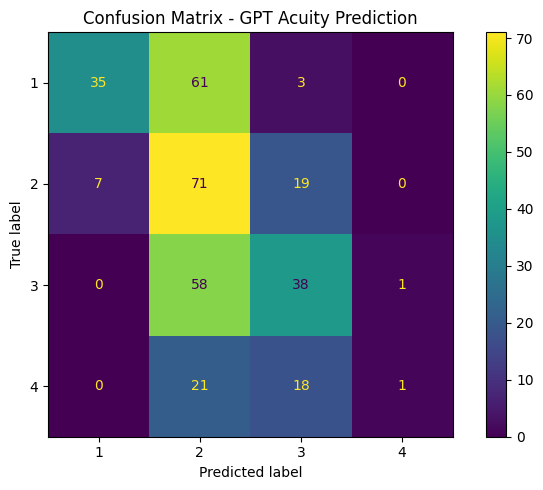

In [17]:
# Confusion matrix for GPT predictions

cm = confusion_matrix(y_true_gpt, y_pred_gpt, labels=[1, 2, 3, 4])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[1, 2, 3, 4]
)

fig, ax = plt.subplots(figsize=(7, 5))
disp.plot(ax=ax, values_format="d")
ax.set_title("Confusion Matrix - GPT Acuity Prediction")
plt.tight_layout()
plt.show()

## Step 15: Calculate under-triage and over-triage

This step calculates under-triage and over-triage rates for GPT.

In this experiment, acuity levels 1 and 2 are treated as urgent, while acuity levels 3 and 4 are treated as non-urgent.

Under-triage means that a truly urgent patient is predicted as non-urgent. This is clinically risky because it may delay treatment.

Over-triage means that a truly non-urgent patient is predicted as urgent. This may waste emergency department resources.

In [18]:
def calculate_under_over_triage(y_true, y_pred, urgent_cutoff=2):
    """
    Under-triage:
    True acuity is urgent, but predicted acuity is non-urgent.

    Over-triage:
    True acuity is non-urgent, but predicted acuity is urgent.
    """
    y_true = pd.Series(y_true).astype(int).reset_index(drop=True)
    y_pred = pd.Series(y_pred).astype(int).reset_index(drop=True)

    true_urgent = y_true <= urgent_cutoff
    true_non_urgent = y_true > urgent_cutoff

    under_triage_count = ((true_urgent) & (y_pred > urgent_cutoff)).sum()
    over_triage_count = ((true_non_urgent) & (y_pred <= urgent_cutoff)).sum()

    under_triage_rate = under_triage_count / true_urgent.sum() * 100
    over_triage_rate = over_triage_count / true_non_urgent.sum() * 100

    return under_triage_rate, over_triage_rate


gpt_under_triage, gpt_over_triage = calculate_under_over_triage(
    y_true_gpt,
    y_pred_gpt,
    urgent_cutoff=2
)

print("GPT under-triage rate (%):", round(gpt_under_triage, 2))
print("GPT over-triage rate (%):", round(gpt_over_triage, 2))

GPT under-triage rate (%): 11.22
GPT over-triage rate (%): 57.66


## Step 16: Create GPT final evaluation table

This step creates the final GPT evaluation table.

The table uses the same style as the model comparison table so that GPT can later be compared with Gemini, Ollama, and the machine learning models.

In [19]:
gpt_final_results = pd.DataFrame([{
    "Model": "GPT",
    "Accuracy (%)": gpt_accuracy * 100,
    "Under-triage (%)": gpt_under_triage,
    "Over-triage (%)": gpt_over_triage,
    "Precision (Macro)": gpt_macro_precision,
    "Recall (Macro)": gpt_macro_recall,
    "F1-Score (Macro)": gpt_macro_f1,
    "Weighted F1": gpt_weighted_f1,
    "Sample Size": len(gpt_eval_df)
}])

display(
    gpt_final_results.round({
        "Accuracy (%)": 2,
        "Under-triage (%)": 2,
        "Over-triage (%)": 2,
        "Precision (Macro)": 4,
        "Recall (Macro)": 4,
        "F1-Score (Macro)": 4,
        "Weighted F1": 4
    })
)

# Save GPT evaluation result
gpt_final_results.to_csv("task1_gpt_evaluation_results.csv", index=False)

print("GPT evaluation results saved as task1_gpt_evaluation_results.csv")

,Model,Accuracy (%),Under-triage (%),Over-triage (%),Precision (Macro),Recall (Macro),F1-Score (Macro),Weighted F1,Sample Size
0,GPT,43.54,11.22,57.66,0.5393,0.3756,0.3598,0.4141,333


GPT evaluation results saved as task1_gpt_evaluation_results.csv


## Step 17: Compare GPT with machine learning reference result

This step compares the GPT result with the best machine learning result from the previous Task 1 experiment.

The best machine learning model was the tuned multi-feature XGBoost model, which achieved 72.12% test accuracy in the full test set.

However, this comparison should be interpreted carefully because GPT was evaluated on a balanced LLM sample, while XGBoost was evaluated on the full test set. Therefore, this table is used as a reference comparison rather than a strict direct comparison.

The GPT result is also analysed using under-triage and over-triage because clinical safety is important in triage prediction.

,Model,Accuracy (%),Under-triage (%),Over-triage (%),Precision (Macro),Recall (Macro),F1-Score (Macro),Weighted F1,Sample Size
0,Tuned Multi-feature XGBoost,72.12,20.50,29.80,0.5452,0.5132,0.5271,0.7197,Full test set
1,GPT,43.54,11.22,57.66,0.5393,0.3756,0.3598,0.4141,333


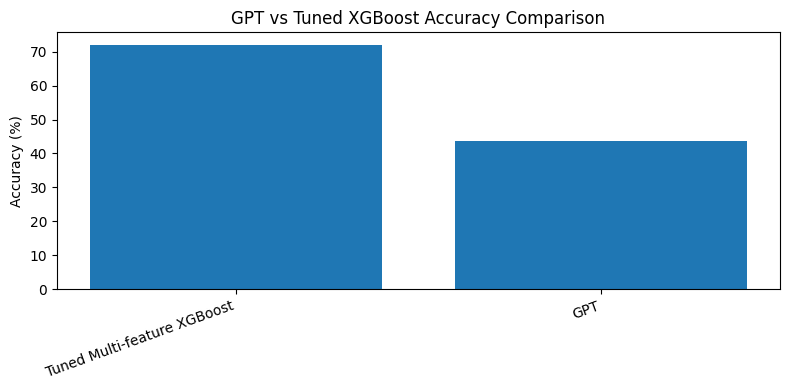

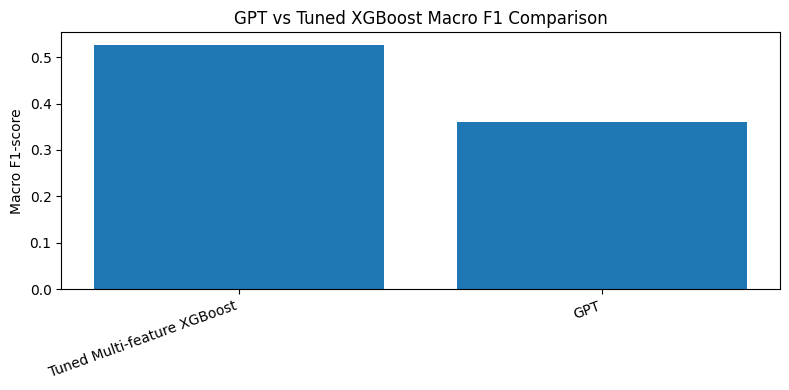

In [22]:
# Reference comparison between GPT and the best ML model

ml_reference_result = {
    "Model": "Tuned Multi-feature XGBoost",
    "Accuracy (%)": 72.12,
    "Under-triage (%)": 20.5,
    "Over-triage (%)": 29.8,
    "Precision (Macro)": 0.5452,
    "Recall (Macro)": 0.5132,
    "F1-Score (Macro)": 0.5271,
    "Weighted F1": 0.7197,
    "Sample Size": "Full test set"
}

comparison_df = pd.concat(
    [
        pd.DataFrame([ml_reference_result]),
        gpt_final_results
    ],
    ignore_index=True
)

display(
    comparison_df.round({
        "Accuracy (%)": 2,
        "Under-triage (%)": 2,
        "Over-triage (%)": 2,
        "Precision (Macro)": 4,
        "Recall (Macro)": 4,
        "F1-Score (Macro)": 4,
        "Weighted F1": 4
    })
)

# Visualise accuracy comparison
plt.figure(figsize=(8, 4))
plt.bar(comparison_df["Model"], comparison_df["Accuracy (%)"])
plt.title("GPT vs Tuned XGBoost Accuracy Comparison")
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

# Visualise macro F1 comparison
plt.figure(figsize=(8, 4))
plt.bar(comparison_df["Model"], comparison_df["F1-Score (Macro)"])
plt.title("GPT vs Tuned XGBoost Macro F1 Comparison")
plt.ylabel("Macro F1-score")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## Step 19: Compare LLM results with the tuned XGBoost reference model

This step combines the Task 1 LLM results from different group members and compares them with the tuned multi-feature XGBoost model.

The comparison includes:
- Tuned multi-feature XGBoost
- GPT
- Gemini
- Local Ollama Mistral using complaint-only input
- Local Ollama Mistral using complaint and vital sign input

The tuned XGBoost result is used as the machine learning reference model. The LLM results are evaluated using the shared LLM evaluation sample, while the XGBoost result is based on the full test set. Therefore, this comparison should be interpreted as a reference comparison rather than a strictly identical test-set comparison.

In [2]:
# Step 19: Compare LLM results with the tuned XGBoost reference model

import pandas as pd
import matplotlib.pyplot as plt

# Combine tuned XGBoost reference result and LLM results from group members
all_model_comparison_results = pd.DataFrame([
    {
        "Model": "Tuned Multi-feature XGBoost",
        "Model Type": "Traditional ML",
        "Accuracy (%)": 72.12,
        "Under-triage (%)": 20.50,
        "Over-triage (%)": 29.80,
        "Precision (Macro)": 0.5452,
        "Recall (Macro)": 0.5132,
        "F1-Score (Macro)": 0.5271,
        "Weighted F1": 0.7197,
        "Sample Size": "Full test set"
    },
    {
        "Model": "GPT",
        "Model Type": "LLM",
        "Accuracy (%)": 43.54,
        "Under-triage (%)": 11.22,
        "Over-triage (%)": 57.66,
        "Precision (Macro)": 0.5393,
        "Recall (Macro)": 0.3756,
        "F1-Score (Macro)": 0.3598,
        "Weighted F1": 0.4141,
        "Sample Size": 333
    },
    {
        "Model": "Gemini-3.1-flash-lite-preview",
        "Model Type": "LLM",
        "Accuracy (%)": 51.18,
        "Under-triage (%)": 17.00,
        "Over-triage (%)": 27.86,
        "Precision (Macro)": 0.4790,
        "Recall (Macro)": 0.4538,
        "F1-Score (Macro)": 0.4541,
        "Weighted F1": 0.5028,
        "Sample Size": 340
    },
    {
        "Model": "Local Ollama Mistral (complaint-only)",
        "Model Type": "LLM",
        "Accuracy (%)": 33.33,
        "Under-triage (%)": 63.96,
        "Over-triage (%)": 2.70,
        "Precision (Macro)": 0.1942,
        "Recall (Macro)": 0.1871,
        "F1-Score (Macro)": 0.1262,
        "Weighted F1": 0.2183,
        "Sample Size": 333
    },
    {
        "Model": "Local Ollama Mistral (complaint+vitals)",
        "Model Type": "LLM",
        "Accuracy (%)": 32.13,
        "Under-triage (%)": 59.16,
        "Over-triage (%)": 8.71,
        "Precision (Macro)": 0.2374,
        "Recall (Macro)": 0.1909,
        "F1-Score (Macro)": 0.1824,
        "Weighted F1": 0.3096,
        "Sample Size": 333
    }
])

# Display final comparison table
display(
    all_model_comparison_results.round({
        "Accuracy (%)": 2,
        "Under-triage (%)": 2,
        "Over-triage (%)": 2,
        "Precision (Macro)": 4,
        "Recall (Macro)": 4,
        "F1-Score (Macro)": 4,
        "Weighted F1": 4
    })
)

# Save comparison table
all_model_comparison_results.to_csv("task1_all_model_comparison_results.csv", index=False)

print("All model comparison results saved as task1_all_model_comparison_results.csv")

,Model,Model Type,Accuracy (%),Under-triage (%),Over-triage (%),Precision (Macro),Recall (Macro),F1-Score (Macro),Weighted F1,Sample Size
0,Tuned Multi-feature XGBoost,Traditional ML,72.12,20.50,29.80,0.5452,0.5132,0.5271,0.7197,Full test set
1,GPT,LLM,43.54,11.22,57.66,0.5393,0.3756,0.3598,0.4141,333
2,Gemini-3.1-flash-lite-preview,LLM,51.18,17.00,27.86,0.4790,0.4538,0.4541,0.5028,340
3,Local Ollama Mistral (complaint-only),LLM,33.33,63.96,2.70,0.1942,0.1871,0.1262,0.2183,333
4,Local Ollama Mistral (complaint+vitals),LLM,32.13,59.16,8.71,0.2374,0.1909,0.1824,0.3096,333


All model comparison results saved as task1_all_model_comparison_results.csv


## Final Interpretation

The tuned multi-feature XGBoost model achieved the best overall performance in Task 1, with the highest accuracy of 72.12%, the highest macro F1-score of 0.5271, and the highest weighted F1-score of 0.7197. This shows that the traditional machine learning model trained on the Task 1 dataset still performs better than the current LLM-based approaches.

Among the LLM models, Gemini-3.1-flash-lite-preview achieved the best overall result, with 51.18% accuracy and a macro F1-score of 0.4541. GPT achieved 43.54% accuracy and a macro F1-score of 0.3598. The local Ollama Mistral models performed worse than GPT and Gemini under the current prompt setting.

The safety metrics show different prediction behaviours. GPT had the lowest under-triage rate among the LLMs, at 11.22%, which means it was less likely to miss truly urgent patients. However, GPT also had a high over-triage rate of 57.66%, meaning it often predicted patients as more urgent than they actually were. This suggests that GPT was more conservative.

Gemini showed a more balanced result among the LLMs, with 17.00% under-triage and 27.86% over-triage. Although it still performed worse than tuned XGBoost, it was the strongest LLM in this comparison.

The local Ollama Mistral models had very high under-triage rates, especially 63.96% for the complaint-only version and 59.16% for the complaint + vitals version. This means they missed many truly urgent patients, which is clinically risky. Adding vital signs improved the macro F1-score from 0.1262 to 0.1824, but the overall performance was still weak.

Overall, tuned XGBoost remains the strongest model for Task 1 triage acuity prediction. The LLM results are useful as supplementary comparisons, but under the current zero-shot prompt-based setting, they do not outperform the trained machine learning model. Future work could improve the LLM approach by using better prompt engineering, few-shot examples, clearer triage rules, or model calibration.